<a href="https://colab.research.google.com/github/ojumoolatimi/Stroke-Risk-Model/blob/main/chembl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline



warnings.filterwarnings("ignore")

In [75]:
!git clone https://github.com/ojumoolatimi/Stroke-Risk-Model.git

fatal: destination path 'Stroke-Risk-Model' already exists and is not an empty directory.


In [76]:
import pandas as pd

def wrangle(url, set_index=None):
    df = pd.read_csv(url)

    if set_index:
        df = df.set_index(set_index)

        #drop unnamed column
        df.drop(columns=['Unnamed: 0'], inplace=True)

        #drop name columns
        df.drop(columns=['Name'], inplace=True)

        #drop smiles
        df.drop(columns=['SMILES'], inplace=True)

        # Handle BACE1 — 2 samples is not learnable
        df = df[~df['Protein'].str.contains('BACE1', na=False)]

    return df

In [77]:

df = wrangle(
    "https://raw.githubusercontent.com/ojumoolatimi/Stroke-Risk-Model/main/molecule_classification_dataset.csv",
    set_index='ChEMBL ID'
)

df.head()

,Molecular Weight,LogP,HBA,HBD,TPSA,Protein
ChEMBL ID,,,,,,
CHEMBL292323,622.77,7.99,8.0,2.0,86.52,EGFR
CHEMBL304414,562.72,7.97,6.0,2.0,68.06,EGFR
CHEMBL62176,282.37,3.19,2.0,1.0,32.34,EGFR
CHEMBL62701,564.70,6.76,8.0,2.0,93.84,EGFR
CHEMBL137617,357.22,4.54,5.0,2.0,74.56,EGFR


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, CHEMBL292323 to CHEMBL4636622
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Molecular Weight  1418 non-null   float64
 1   LogP              1410 non-null   float64
 2   HBA               1410 non-null   float64
 3   HBD               1410 non-null   float64
 4   TPSA              1410 non-null   float64
 5   Protein           1420 non-null   object 
dtypes: float64(5), object(1)
memory usage: 77.7+ KB


Protein
DRD2     89.507042
EGFR      6.408451
HDAC1     4.084507
Name: proportion, dtype: float64


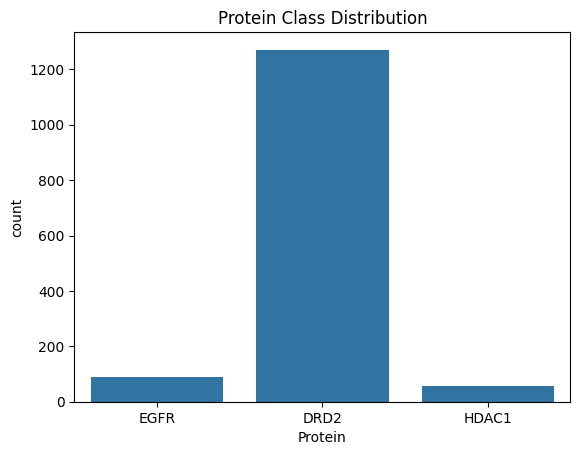

In [79]:
# Target distribution
sns.countplot(data=df, x='Protein')
plt.title('Protein Class Distribution')

# Percentage breakdown
print(df['Protein'].value_counts(normalize=True) * 100)

In [80]:
le = LabelEncoder()
y = le.fit_transform(df['Protein'])

In [81]:
X = df.drop(columns=['Protein'])


In [82]:
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1420, 5)
y shape: (1420,)


In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (1136, 5)
y_train shape: (1136,)
X_test shape: (284, 5)
y_test shape: (284,)


In [84]:
over_sampling = RandomOverSampler(random_state= 42)
X_train_over, y_train_over = over_sampling.fit_resample(X_train, y_train)
print('X_train_over shape:', X_train_over.shape)
print('y_train_over shape:', y_train_over.shape)

X_train_over shape: (3060, 5)
y_train_over shape: (3060,)


Build model

In [85]:
# Convert to Series first, then value_counts
acc_baseline = pd.Series(y_train).value_counts(normalize=True).max()
print('Baseline Accuracy:', round(acc_baseline, 4))

Baseline Accuracy: 0.8979


In [86]:
clf = make_pipeline(
    SimpleImputer(),
    GradientBoostingClassifier(random_state=42)

)

In [87]:
params = {
    'simpleimputer__strategy': ['mean', 'median'],
    'gradientboostingclassifier__n_estimators': range(100, 600, 100),
    'gradientboostingclassifier__max_depth': range(1, 10),
}

In [88]:
model = GridSearchCV(clf, params, cv=5, n_jobs=-1, verbose=1)
model.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                       ('gradientboostingclassifier',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'gradientboostingclassifier__max_depth': range(1, 10),
                         'gradientboostingclassifier__n_estimators': range(100, 600, 100),
                         'simpleimputer__strategy': ['mean', 'median']},
             verbose=1)

In [90]:
pd.DataFrame(model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gradientboostingclassifier__max_depth,param_gradientboostingclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.394631,0.222032,0.014838,0.008860,1,100,mean,"{'gradientboostingclassifier__max_depth': 1, '...",0.880719,0.887255,0.851307,0.869281,0.862745,0.870261,0.012766,89
1,0.780288,0.014748,0.008712,0.002860,1,100,median,"{'gradientboostingclassifier__max_depth': 1, '...",0.880719,0.887255,0.851307,0.869281,0.862745,0.870261,0.012766,89
2,2.149671,0.464948,0.014096,0.006220,1,200,mean,"{'gradientboostingclassifier__max_depth': 1, '...",0.915033,0.921569,0.879085,0.905229,0.901961,0.904575,0.014527,87
3,1.497794,0.014967,0.009304,0.000410,1,200,median,"{'gradientboostingclassifier__max_depth': 1, '...",0.915033,0.921569,0.879085,0.905229,0.901961,0.904575,0.014527,87
4,2.480157,0.466038,0.012728,0.003522,1,300,mean,"{'gradientboostingclassifier__max_depth': 1, '...",0.923203,0.929739,0.903595,0.913399,0.908497,0.915686,0.009561,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,14.153500,0.272710,0.032890,0.001405,9,300,median,"{'gradientboostingclassifier__max_depth': 9, '...",0.990196,0.998366,0.991830,0.993464,0.993464,0.993464,0.002734,2
86,14.754975,0.159570,0.041698,0.016277,9,400,mean,"{'gradientboostingclassifier__max_depth': 9, '...",0.991830,1.000000,0.991830,0.990196,0.991830,0.993137,0.003489,9
87,14.988437,0.080608,0.040154,0.008529,9,400,median,"{'gradientboostingclassifier__max_depth': 9, '...",0.990196,0.998366,0.991830,0.993464,0.993464,0.993464,0.002734,2
88,15.524012,0.648447,0.044722,0.019414,9,500,mean,"{'gradientboostingclassifier__max_depth': 9, '...",0.991830,1.000000,0.991830,0.990196,0.991830,0.993137,0.003489,9


In [91]:
model.best_params_

{'gradientboostingclassifier__max_depth': 9,
 'gradientboostingclassifier__n_estimators': 100,
 'simpleimputer__strategy': 'median'}

In [92]:
acc_train = model.score(X_train_over, y_train_over)
acc_test = model.score(X_test, y_test)
print("Training Accuracy:", round(acc_train, 4))
print("Validation Accuracy:", round(acc_test, 4))

Training Accuracy: 1.0
Validation Accuracy: 0.9542


In [98]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Get predictions
y_pred = search.best_estimator_.predict(X_test)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['BACE1', 'DRD2', 'EGFR', 'HDAC1']  # your 4 protein classes
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix — Molecule Protein Classification')
plt.tight_layout()
plt.show()

NameError: name 'search' is not defined

NameError: name 'cm' is not defined